# Transformada de Fourier

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

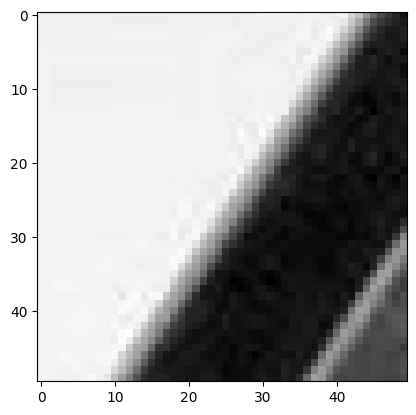

In [2]:
ruta = r'Copia de Casa con bordes.jpg'
ima = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
ima = ima[250:300, 150:200]
plt.imshow(ima, cmap='gray')

# Funciones previas
TF, ATF, padding, normalización loga y normal y aplica filtros

In [3]:
def TF_2d_casera(imagen):
    # Sacamos las dimensiones de la imagen
    M, N = imagen.shape
    imagen = imagen.astype(float) #cambiamos el tipo de dato para hacer las operaciones
    # Creamos una matriz donde quedará la TF
    TF = np.zeros_like(imagen, dtype=complex)

    # Aplicamos la fórmula para poder hacer que la TF quede en la misma forma
    ima_cambiada = np.zeros_like(imagen)
    for y in range(M):
        for x in range(N):
            ima_cambiada[y][x] = imagen[y][x] * (-1) ** (x + y)

    # Hacemos las 4 sumatorias (las de la imagen y las de la trans)
    for v in range(M): # Fila de la imagen transformada
        for u in range(N): # Columan de la imagen transformada
            for y in range(M): # Fila en la imagen original
                for x in range(N): # Columna en la imagen original
                    # Calculamos el exponente:
                    # Para usar complejos en python usamos el formato "1j"
                    TF[v][u] += (ima_cambiada[y][x] * np.exp(-1j * 2 * np.pi * ((u * x) / N + (v * y) / M)))
    return TF


In [4]:
def ATF_2d_casera(imagen):
    # Sacamos las dimensiones de la imagen
    M, N = imagen.shape
    # Creamos una matriz donde quedará la TF
    TF = np.zeros_like(imagen, dtype=complex)
    
    # Hacemos las 4 sumatorias (las de la imagen y las de la trans)
    for v in range(M): # Fila de la imagen transformada
        for u in range(N): # Columan de la imagen transformada
            for y in range(M): # Fila en la imagen original
                for x in range(N): # Columna en la imagen original
                    # Calculamos el exponente:
                    # Para usar complejos en python usamos el formato "1j"
                    TF[v][u] += (imagen[y][x] * np.exp(1j * 2 * np.pi * ((u * x) / N + (v * y) / M)))
    return np.abs(TF / (M * N))


In [5]:
def normalizacion_loga(trans):
    loga = np.log(np.abs(trans) + 1)
    max = np.max(loga)
    min = np.min(loga)
    M, N = loga.shape
    loga_norm = np.zeros((M, N))
    #normalizar 
    for j in range(M):
        for i in range(N):
            loga_norm[j][i] = int((loga[j][i] - min) * (255.0 / (max - min)))
    return np.array(loga_norm, dtype=np.uint8)

In [6]:
def normalizacion_ATF(TF):
    max = np.max(TF)
    min = np.min(TF)
    M, N = TF.shape
    TF_norm = np.zeros((M, N))
    #normalizar 
    for j in range(M):
        for i in range(N):
            TF_norm[j][i] = int((TF[j][i] - min) * (255.0 / (max - min)))
    return np.array(TF_norm, dtype=np.uint8)

In [7]:
def aplica_filtro_trans(TF, filtro):
    M, N = TF.shape
    aplica_filtro = np.zeros_like(TF)
    for j in range(M):
        for i in range(N):
            aplica_filtro[j][i] = TF[j][i] * filtro[j][i]
    return aplica_filtro

###  Transformada de Fourier general para usar con todos los filtros

In [8]:
TF = TF_2d_casera(ima)

# Ideal Low pass filter
Corta las componentes de las altas frecuencias que están en cierta distancia $D_0$ del origen de la transformación.
La ecuación está dada por:
$$ H(u, v) = \begin{cases} 1 \text{ if } D(u, v) \leq D_{0}\\
0 \text{ if } D(u, v) > D_0
\end{cases} $$

In [9]:
def ideal_low_pass_filter(imagen, D0):
    M, N = imagen.shape
    # Creamos el filtro del tamano de la imagen
    filtro = np.zeros_like(imagen)
    # Centramos el filtro
    centro_x = int(N / 2)
    centro_y = int(M / 2)
    # Calculamos la distancia hasta el corte D0 para cada Pixel:
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt((x - centro_x) ** 2 + (y - centro_y) ** 2)
            if distancia <= D0:
                filtro[y][x] = 1
            # else:
            #     filtro[y][x] = 1
    return filtro

In [10]:
D0 = 5
filter_ideal_lowpass = ideal_low_pass_filter(ima, D0)

In [11]:
aplicada = aplica_filtro_trans(TF, filter_ideal_lowpass)

In [12]:
ATF = ATF_2d_casera(aplicada)

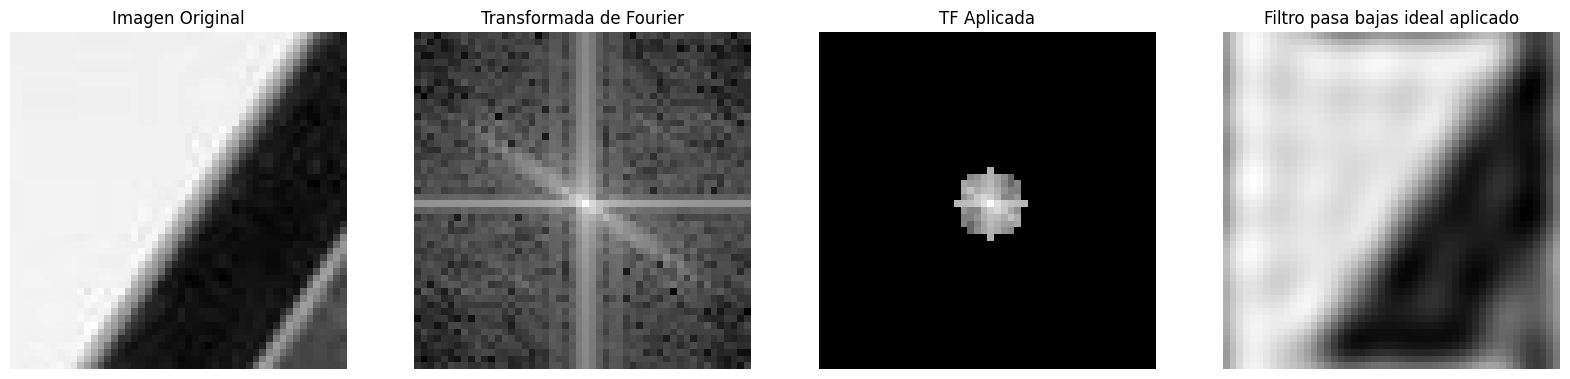

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(aplicada), cmap='gray')
axs[2].set_title('TF Aplicada')
axs[2].axis('off')
axs[3].imshow(normalizacion_ATF(ATF), cmap='gray')
axs[3].set_title('Filtro pasa bajas ideal aplicado')
axs[3].axis('off')
plt.show()

# Filtro Butterworth Lowpass
Este filtro tiene un corte menos abrupto y depende de una variable $n$ que nnos dice que tan rápido o lento queremos cortar el filtro.

The transfer function of a BF of order $n$ with cutoff frequency at distance $D_0$ from the origin is defined as:
$$ H(u,v) = \frac{1}{1 + [D(u, v) / D_0] ^{2n}} $$

Es muy similar a un filtro gaussiano, pero tiene un poco más de libertad al dejar escoger la zona de corte.

In [14]:
def Filt_butterworth_pb(imagen, D0, n):
    M, N = imagen.shape
    # Espacio para el filtro
    filtro = np.zeros_like(imagen).astype(float)
    # Corremos por toda la imagen
    # necesitamos la distancia desde el centro hasta el pixel
    centro_x = int(N/2)
    centro_y = int(M/2)
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt( (x - centro_x) ** 2 + (y - centro_y) ** 2 )
            if distancia <= D0:
                filtro[y][x] = 1 / (1 + (distancia / D0) ** (2 * n))
    return filtro

In [15]:
n = 3
D0 = 10
fil_butt_pb = Filt_butterworth_pb(ima, D0, n)

In [16]:
TFyfiltbutt_pb = aplica_filtro_trans(TF, fil_butt_pb)

In [17]:
ATF_buttpb = ATF_2d_casera(TFyfiltbutt_pb)

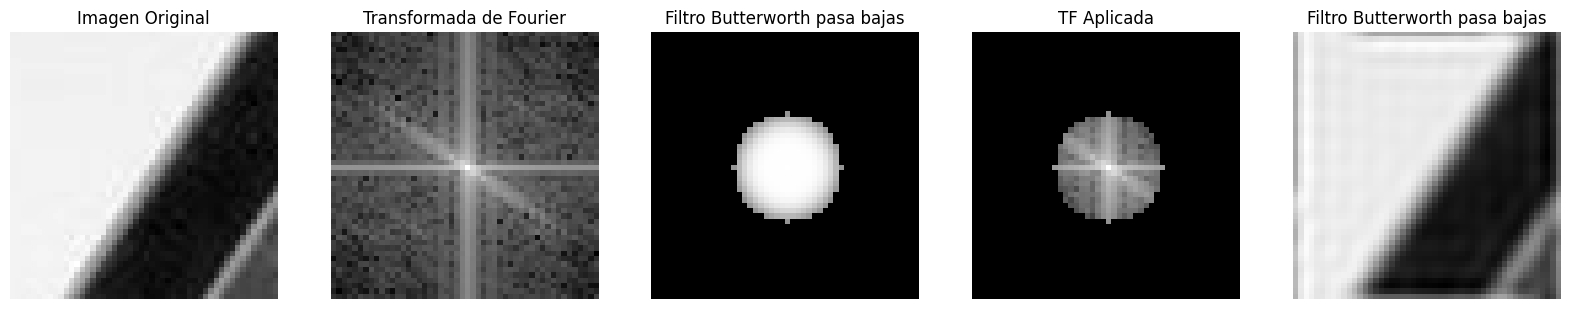

In [18]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(fil_butt_pb), cmap='gray')
axs[2].set_title('Filtro Butterworth pasa bajas')
axs[2].axis('off')
axs[3].imshow(normalizacion_loga(TFyfiltbutt_pb), cmap='gray')
axs[3].set_title('TF Aplicada')
axs[3].axis('off')
axs[4].imshow(normalizacion_ATF(ATF_buttpb), cmap='gray')
axs[4].set_title('Filtro Butterworth pasa bajas')
axs[4].axis('off')
plt.show()

# Filtro Gaussiano
The transfer function of a Gaussian lowpass filter is 
$$ H(u, v) = e^{-D^2(u, v) / 2D_0^2} $$


In [19]:
def Gaussian_filter_pb(imagen, D0):
    M, N = imagen.shape
    # Filtro
    filtro = np.zeros_like(imagen).astype(float)
    # necesitamos la distancia desde el centro hasta el pixel
    centro_x = int(N/2)
    centro_y = int(M/2)
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt( (x - centro_x) ** 2 + (y - centro_y) ** 2 )
            if distancia <= D0:
                filtro[y][x] = np.exp(- (distancia ** 2) / (2 * (D0 ** 2)))
    return filtro

In [20]:
D0 = 10
Filtro_gauss_pb = Gaussian_filter_pb(ima, D0)

In [21]:
TF_gauss_pb = aplica_filtro_trans(TF, Filtro_gauss_pb)

In [22]:
ATF_gauss_pb = ATF_2d_casera(TF_gauss_pb)

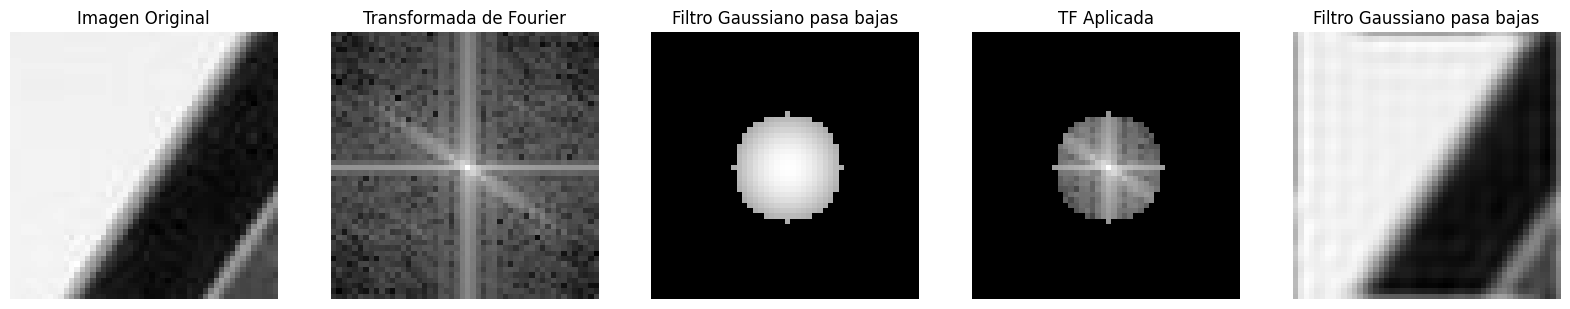

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(Filtro_gauss_pb), cmap='gray')
axs[2].set_title('Filtro Gaussiano pasa bajas')
axs[2].axis('off')
axs[3].imshow(normalizacion_loga(TF_gauss_pb), cmap='gray')
axs[3].set_title('TF Aplicada')
axs[3].axis('off')
axs[4].imshow(normalizacion_ATF(ATF_gauss_pb), cmap='gray')
axs[4].set_title('Filtro Gaussiano pasa bajas')
axs[4].axis('off')
plt.show()

# Aplicaciones
* Se usan para conectar texto roto (broken text).
* Remover arrugas en una fotografía (remover blemishes)

# Filtros pasa altos
$$ H_{hp}(u, v) = 1 - H_{lp} $$

## Filtro ideal pasa altas
$$ H(u, v)= \begin{cases} 
0 \text{ if } D(u, v) \leq D_0 \\
1 \text{ if } D(u, v) > D_0 
\end{cases}$$
Donde $D_0$ es la zona de corte.

In [24]:
def ideal_high_pass_filter(imagen, D0):
    M, N = imagen.shape
    # Creamos el filtro del tamano de la imagen
    filtro = np.zeros_like(imagen)
    # Centramos el filtro
    centro_x = int(N / 2)
    centro_y = int(M / 2)
    # Calculamos la distancia hasta el corte D0 para cada Pixel:
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt((x - centro_x) ** 2 + (y - centro_y) ** 2)
            if distancia >= D0:
                filtro[y][x] = 1
    return filtro

In [25]:
D0 = 5
ideal_pa_filter = ideal_high_pass_filter(ima, D0)

In [26]:
TF_pa_ideal = aplica_filtro_trans(TF, ideal_pa_filter)

In [27]:
ATF_pa_ideal = ATF_2d_casera(TF_pa_ideal)

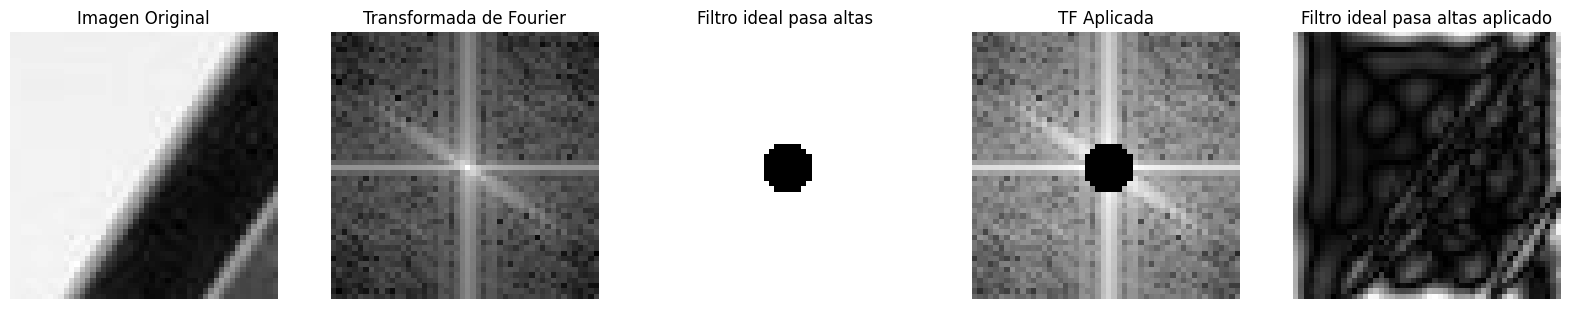

In [28]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(ideal_pa_filter), cmap='gray')
axs[2].set_title('Filtro ideal pasa altas')
axs[2].axis('off')
axs[3].imshow(normalizacion_loga(TF_pa_ideal), cmap='gray')
axs[3].set_title('TF Aplicada')
axs[3].axis('off')
axs[4].imshow(normalizacion_ATF(ATF_pa_ideal), cmap='gray')
axs[4].set_title('Filtro ideal pasa altas aplicado')
axs[4].axis('off')
plt.show()

# Filtro Butterworth Highpass
Este filtro tiene un corte menos abrupto y depende de una variable $n$ que nnos dice que tan rápido o lento queremos cortar el filtro.

The transfer function of a BF of order $n$ with cutoff frequency at distance $D_0$ from the origin is defined as:
$$ H(u,v) = \frac{1}{1 + [D(u, v) / D_0] ^{2n}} $$

Es muy similar a un filtro gaussiano, pero tiene un poco más de libertad al dejar escoger la zona de corte.

In [29]:
def Filt_butterworth_pa(imagen, D0, n):
    M, N = imagen.shape
    # Espacio para el filtro
    filtro = np.zeros_like(imagen).astype(float)
    # Corremos por toda la imagen
    # necesitamos la distancia desde el centro hasta el pixel
    centro_x = int(N/2)
    centro_y = int(M/2)
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt( (x - centro_x) ** 2 + (y - centro_y) ** 2 )
            if distancia >= D0:
                filtro[y][x] = 1 - (1 / (1 + (distancia / D0) ** (2 * n)))
    return filtro

In [30]:
n = 3
D0 = 10
fil_butt_pa = Filt_butterworth_pa(ima, D0, n)

In [31]:
TFyfiltbutt_pa = aplica_filtro_trans(TF, fil_butt_pa)

In [32]:
ATF_buttpa = ATF_2d_casera(TFyfiltbutt_pa)

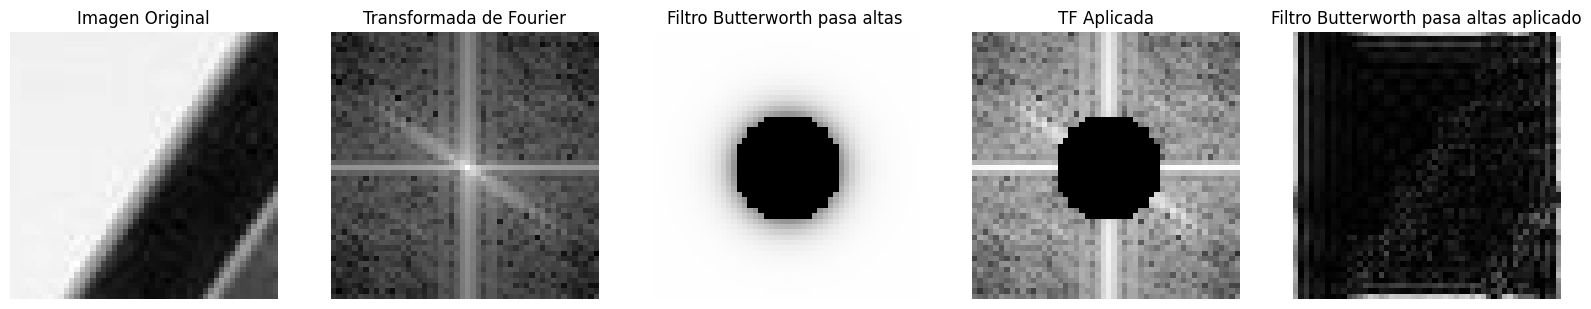

In [33]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(fil_butt_pa), cmap='gray')
axs[2].set_title('Filtro Butterworth pasa altas')
axs[2].axis('off')
axs[3].imshow(normalizacion_loga(TFyfiltbutt_pa), cmap='gray')
axs[3].set_title('TF Aplicada')
axs[3].axis('off')
axs[4].imshow(normalizacion_ATF(ATF_buttpa), cmap='gray')
axs[4].set_title('Filtro Butterworth pasa altas aplicado')
axs[4].axis('off')
plt.show()

## Filtro Gaussiano pasa altas
$$ H(u, v) = 1 - e^{-D^2(u, v)/2D_0} $$


In [34]:
def Gaussian_filter_pa(imagen, D0):
    M, N = imagen.shape
    # Filtro
    filtro = np.zeros_like(imagen).astype(float)
    # necesitamos la distancia desde el centro hasta el pixel
    centro_x = int(N/2)
    centro_y = int(M/2)
    for y in range(M):
        for x in range(N):
            distancia = np.sqrt( (x - centro_x) ** 2 + (y - centro_y) ** 2 )
            if distancia >= D0:
                filtro[y][x] = np.exp(- (distancia ** 2) / (2 * (D0 ** 2)))
    return filtro

In [35]:
D0 = 10
Filtro_gauss_pa = Gaussian_filter_pa(ima, D0)

In [36]:
TF_gauss_pa = aplica_filtro_trans(TF, Filtro_gauss_pb)

In [37]:
ATF_gauss_pa = ATF_2d_casera(TF_gauss_pa)

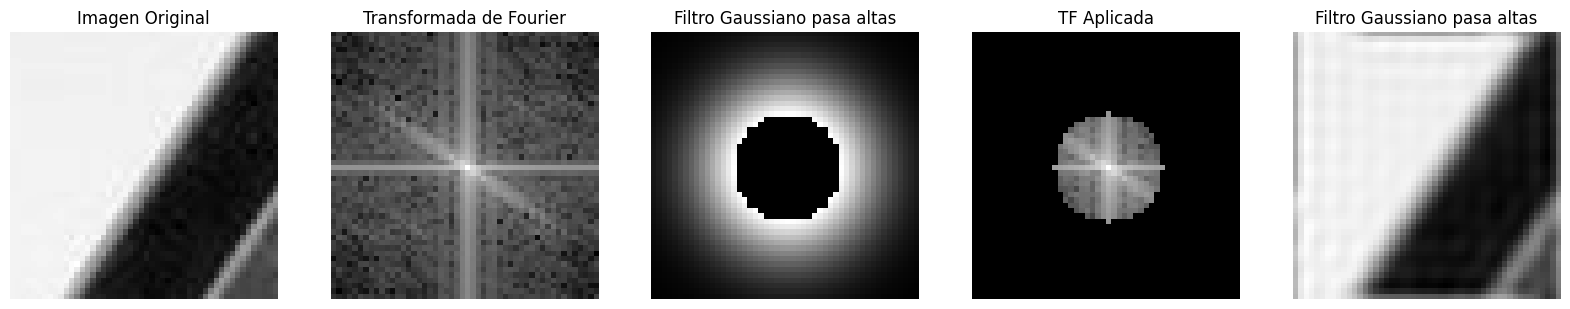

In [38]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(normalizacion_loga(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(normalizacion_loga(Filtro_gauss_pa), cmap='gray')
axs[2].set_title('Filtro Gaussiano pasa altas')
axs[2].axis('off')
axs[3].imshow(normalizacion_loga(TF_gauss_pa), cmap='gray')
axs[3].set_title('TF Aplicada')
axs[3].axis('off')
axs[4].imshow(normalizacion_ATF(ATF_gauss_pa), cmap='gray')
axs[4].set_title('Filtro Gaussiano pasa altas')
axs[4].axis('off')
plt.show()

# Filtro direccional
